# 03 — Experiment 2: ridge-augmented SCM (ASCM) in tokenizer latent space

The collaborator's notebook-15 method transplanted to the latent panel: ridge-augmented
SCM (Ben-Michael, Feller & Rothstein 2021, Eq. 18), solved in closed form,

  min_w (1/2λ)‖x − Xw‖² + (1/2)‖w − w_SCM‖²  s.t. Σw = 1,

anchored on notebook 02's SCM weights. Negative weights are allowed (extrapolation), no
intercept. λ is chosen per site × sensor × fit-window by **leave-one-fit-period-out CV**
over the fit window only (grid logspace(−4, 4, 81), notebook 15's grid; the SCM anchor
is refit once per fold, not per λ — removing notebook 15's 81× redundant refits).

Same donors, z-scoring, fit windows (w8 = P01–P08, w9 = P01–P09), validation schemes
(`frozen_joint`, `expanding`), flags, and quality-sensitivity arm as notebook 02.

**Honesty diagnostics carried into the outputs:** λ at a grid boundary; weight distance
from SCM; number/total of negative weights; and the **latent-range check** — with
negative weights the weighted latent can leave the tokenizer's trained [0, 1] range, so
the fraction of the 980 values outside [0, 1] is recorded for every ASCM counterfactual
(SCM's convex combinations cannot leave it). One scale note: the penalty acts on the sum
of squared errors over periods × 980 latent dims, so a given λ augments more strongly
here than in notebook 15's 11-feature space — the CV choice of λ absorbs this, but λ
values are not comparable across the two spaces.

**Inputs:** `latents_biweekly.npz`, `panel_latent_index.csv`, `panel_knn_donors.csv`,
`panel_scm_weights.csv`. **Outputs:** `panel_ascm_weights.csv`,
`panel_ascm_lambda_cv.csv`, `panel_ascm_validation.csv`, `panel_scm_vs_ascm.csv`,
`panel_ascm_effects.csv`, figures.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

ROOT = Path("/data/wang/junh/githubs/latent-synthetic-control")
TS = ROOT / "Satellite" / "notebooks" / "ts_SCM_ASCM"
LATD = ROOT / "Satellite" / "data" / "embeddings_tok_panel"

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titlesize": 10,
    "axes.labelsize": 9, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "figure.titlesize": 12,
})

SENSORS = ("sentinel1", "sentinel2")
TRAIN8, TRAIN9, POST = list(range(1, 9)), list(range(1, 10)), list(range(11, 21))
J = 5
LAMBDAS = np.logspace(-4, 4, 81)          # notebook 15's grid

idx = pd.read_csv(TS / "panel_latent_index.csv")
roster = pd.read_csv(ROOT / "Satellite" / "data" / "daily_datasets" / "selected_site_sample.csv")
treatments = sorted(roster.query("group == 'treatment'")["site_id"])

_z = np.load(LATD / "latents_biweekly.npz")
lat = {tuple(k.split("|")): _z[k].ravel().astype(np.float64) for k in _z.files}
D = len(next(iter(lat.values())))

seq_of = idx.set_index(["site_id", "sensor", "period_id"])["seq"].to_dict()
pid_of_seq = {v: k[2] for k, v in seq_of.items()}
vfrac = idx.set_index(["site_id", "sensor", "period_id"])["valid_pixel_fraction"].to_dict()

def L(site, sensor, seq): return lat.get((site, sensor, pid_of_seq[seq]))
def ok(site, sensor, seq, arm):
    v = lat.get((site, sensor, pid_of_seq[seq]))
    if v is None: return False
    if arm == "quality40":
        f = vfrac.get((site, sensor, pid_of_seq[seq]), np.nan)
        return bool(np.isfinite(f) and f >= 0.40)
    return True

# pooled P01-08 scaler — identical construction to notebook 02
scaler = {}
for sensor in SENSORS:
    X = np.stack([lat[(s, sensor, pid_of_seq[q])] for s in roster["site_id"]
                  for q in TRAIN8 if (s, sensor, pid_of_seq[q]) in lat])
    mu = X.mean(axis=0); sd = X.std(axis=0, ddof=1)
    sd[~np.isfinite(sd) | (sd == 0)] = 1.0
    scaler[sensor] = (mu, sd)

def Z(site, sensor, seq):
    v = L(site, sensor, seq)
    if v is None: return None
    mu, sd = scaler[sensor]
    return (v - mu) / sd

don = pd.read_csv(TS / "panel_knn_donors.csv")
donors = {(r_arm, r_sen, r_tid): g.sort_values("rank")["counterfactual_site_id"].tolist()
          for (r_arm, r_sen, r_tid), g in
          don.groupby(["arm", "sensor", "treatment_site_id"])}

wsc = pd.read_csv(TS / "panel_scm_weights.csv")
def scm_w(arm, sensor, tid, window):
    g = wsc.query("arm == @arm and sensor == @sensor and "
                  "treatment_site_id == @tid and fit_window == @window")
    order = donors[(arm, sensor, tid)]
    return g.set_index("donor").loc[order, "weight"].to_numpy()

print(f"{len(lat)} latents, D = {D}; donors and SCM weights loaded")

2322 latents, D = 980; donors and SCM weights loaded


## Fit machinery (shared with notebook 02) + closed-form ridge ASCM

In [2]:
def usable(tid, sensor, seqs, dl, arm):
    return [q for q in seqs
            if ok(tid, sensor, q, arm) and all(ok(c, sensor, q, arm) for c in dl)]

def design(tid, sensor, seqs, dl):
    y = np.stack([Z(tid, sensor, q) for q in seqs]).reshape(-1)          # (T*D,)
    X = np.stack([np.stack([Z(c, sensor, q) for q in seqs]).reshape(-1)
                  for c in dl]).T                                        # (T*D, J)
    return y, X

def scm_fit(y, X):
    Jn = X.shape[1]
    def obj(w):
        r = y - X @ w
        return float(np.mean(r * r))
    res = minimize(obj, np.full(Jn, 1.0 / Jn), method="SLSQP",
                   bounds=[(0.0, 1.0)] * Jn,
                   constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1.0}],
                   options={"maxiter": 5000, "ftol": 1e-12})
    assert res.success, res.message
    return res.x

def ascm_fit(y, X, w_scm, lam):
    """closed-form KKT solve of (1/2lam)||y-Xw||^2 + (1/2)||w-w_scm||^2, sum w = 1."""
    Jn = X.shape[1]
    H = np.eye(Jn) + X.T @ X / lam
    b = w_scm + X.T @ y / lam
    A = np.zeros((Jn + 1, Jn + 1))
    A[:Jn, :Jn] = H; A[:Jn, Jn] = 1.0; A[Jn, :Jn] = 1.0
    rhs = np.concatenate([b, [1.0]])
    w = np.linalg.solve(A, rhs)[:Jn]
    assert abs(w.sum() - 1.0) < 1e-9
    return w

def rmse(w, tid, sensor, seqs, dl):
    y, X = design(tid, sensor, seqs, dl)
    r = y - X @ w
    return float(np.sqrt(np.mean(r * r)))

## λ selection (leave-one-fit-period-out CV) + final ASCM fits

In [3]:
cv_rows, w_rows, WA = [], [], {}
for arm in ("main", "quality40"):
    for sensor in SENSORS:
        for tid in treatments:
            dl = donors.get((arm, sensor, tid))
            if dl is None:
                continue   # not estimable under the quality-40 filter (see notebook 02)
            for wname, window in (("P01-08", TRAIN8), ("P01-09", TRAIN9)):
                seqs = usable(tid, sensor, window, dl, arm)
                if len(seqs) < 2:
                    continue
                cv_sse = np.zeros(len(LAMBDAS))
                for hold in seqs:
                    rest = [q for q in seqs if q != hold]
                    if len(rest) < 2:
                        continue
                    y_r, X_r = design(tid, sensor, rest, dl)
                    w_scm_f = scm_fit(y_r, X_r)                 # once per fold
                    y_h, X_h = design(tid, sensor, [hold], dl)
                    for li, lam in enumerate(LAMBDAS):
                        w = ascm_fit(y_r, X_r, w_scm_f, lam)
                        r = y_h - X_h @ w
                        cv_sse[li] += float(r @ r)
                best = int(np.argmin(cv_sse))
                lam = float(LAMBDAS[best])
                for li, lam_i in enumerate(LAMBDAS):
                    cv_rows.append({"arm": arm, "sensor": sensor,
                                    "treatment_site_id": tid, "fit_window": wname,
                                    "lambda": float(lam_i), "cv_sse": float(cv_sse[li]),
                                    "chosen": li == best})
                # final fit on the full window, anchored on notebook 02's SCM weights
                y, X = design(tid, sensor, seqs, dl)
                w0 = scm_w(arm, sensor, tid, wname)
                w = ascm_fit(y, X, w0, lam)
                mse_a = float(np.mean((y - X @ w) ** 2))
                mse_s = float(np.mean((y - X @ w0) ** 2))
                assert mse_a <= mse_s + 1e-12, (arm, sensor, tid, wname)
                WA[(arm, sensor, tid, wname)] = (w, dl, seqs, lam)
                neg = w[w < 0]
                for c, wi in zip(dl, w):
                    w_rows.append({"arm": arm, "sensor": sensor,
                                   "treatment_site_id": tid, "fit_window": wname,
                                   "donor": c, "weight": float(wi), "lambda": lam,
                                   "lambda_at_boundary":
                                       best in (0, len(LAMBDAS) - 1),
                                   "weight_distance_from_scm":
                                       float(np.linalg.norm(w - w0)),
                                   "n_negative_weights": int((w < 0).sum()),
                                   "sum_negative_weight": float(-neg.sum()),
                                   "n_train_periods": len(seqs)})

wa = pd.DataFrame(w_rows)
assert len(wa.query("arm == 'main'")) == 2 * 10 * 2 * J
wa.to_csv(TS / "panel_ascm_weights.csv", index=False)
pd.DataFrame(cv_rows).to_csv(TS / "panel_ascm_lambda_cv.csv", index=False)
print("saved:", TS / "panel_ascm_weights.csv", wa.shape)
print("saved:", TS / "panel_ascm_lambda_cv.csv", len(cv_rows), "rows")

lam_tab = wa.drop_duplicates(["arm", "sensor", "treatment_site_id", "fit_window"])
print("\nchosen lambda (main arm, w8):")
print(lam_tab.query("arm == 'main' and fit_window == 'P01-08'")
      .pivot_table(index="treatment_site_id", columns="sensor", values="lambda")
      .round(3))
print("boundary hits:", int(lam_tab["lambda_at_boundary"].sum()), "of", len(lam_tab))
print("fits with negative weights (main, w8):")
print(lam_tab.query("arm == 'main' and fit_window == 'P01-08' and n_negative_weights > 0")
      [["sensor", "treatment_site_id", "n_negative_weights", "sum_negative_weight",
        "weight_distance_from_scm"]].to_string(index=False))

saved: /data/wang/junh/githubs/latent-synthetic-control/Satellite/notebooks/ts_SCM_ASCM/panel_ascm_weights.csv (400, 12)
saved: /data/wang/junh/githubs/latent-synthetic-control/Satellite/notebooks/ts_SCM_ASCM/panel_ascm_lambda_cv.csv 6480 rows

chosen lambda (main arm, w8):
sensor             sentinel1  sentinel2
treatment_site_id                      
treatment_0001           0.0    630.957
treatment_0002           0.0  10000.000
treatment_0003           0.0  10000.000
treatment_0004       10000.0  10000.000
treatment_0005       10000.0  10000.000
treatment_0006       10000.0  10000.000
treatment_0007           0.0  10000.000
treatment_0008       10000.0  10000.000
treatment_0009       10000.0      0.000
treatment_0010           0.0  10000.000
boundary hits: 72 of 80
fits with negative weights (main, w8):
Empty DataFrame
Columns: [sensor, treatment_site_id, n_negative_weights, sum_negative_weight, weight_distance_from_scm]
Index: []


## Validation (both schemes) + latent-range diagnostics

In [4]:
def flags(train, valid):
    ratio = valid / train if train > 0 else np.inf
    fr = "good" if ratio <= 1.5 else ("caution" if ratio <= 2.0 else "poor")
    return ratio, fr, ("pass" if valid < 1.0 else "FAIL")

def latent_range(w, sensor, dl, seq):
    """weighted RAW latent (decode space): min, max, frac outside [0,1]."""
    v = np.tensordot(w, np.stack([L(c, sensor, seq) for c in dl]), axes=1)
    return float(v.min()), float(v.max()), float(((v < 0) | (v > 1)).mean())

val_rows = []
for arm in ("main", "quality40"):
    for sensor in SENSORS:
        for tid in treatments:
            f8 = WA.get((arm, sensor, tid, "P01-08"))
            f9 = WA.get((arm, sensor, tid, "P01-09"))
            if f8 is None or f9 is None:
                continue
            w8, dl, seqs8, lam8 = f8
            w9, _, seqs9, lam9 = f9
            tr8 = rmse(w8, tid, sensor, seqs8, dl)
            tr9 = rmse(w9, tid, sensor, seqs9, dl)
            entries = [("frozen_joint", "pooled", w8, tr8,
                        usable(tid, sensor, [9, 10], dl, arm), len(seqs8)),
                       ("expanding", "P09", w8, tr8,
                        usable(tid, sensor, [9], dl, arm), len(seqs8)),
                       ("expanding", "P10", w9, tr9,
                        usable(tid, sensor, [10], dl, arm), len(seqs9))]
            for scheme, ep, w, tr, seqs, ntr in entries:
                row = {"arm": arm, "sensor": sensor, "treatment_site_id": tid,
                       "scheme": scheme, "eval_period": ep, "train_rmse": tr,
                       "n_train_periods": ntr, "n_valid_periods": len(seqs)}
                if not seqs:
                    row.update({"valid_rmse": np.nan, "ratio": np.nan,
                                "flag_ratio": "no_data", "flag_level": "no_data",
                                "latent_frac_outside_01": np.nan})
                else:
                    v = rmse(w, tid, sensor, seqs, dl)
                    ratio, fr, fl = flags(tr, v)
                    fo = float(np.mean([latent_range(w, sensor, dl, q)[2]
                                        for q in seqs]))
                    row.update({"valid_rmse": v, "ratio": ratio, "flag_ratio": fr,
                                "flag_level": fl, "latent_frac_outside_01": fo})
                val_rows.append(row)

vala = pd.DataFrame(val_rows)
assert len(vala.query("arm == 'main'")) == 2 * 10 * 3
vala.to_csv(TS / "panel_ascm_validation.csv", index=False)
print("saved:", TS / "panel_ascm_validation.csv", vala.shape)
print("\nmax latent fraction outside [0,1] across ASCM validation predictions:",
      f"{vala['latent_frac_outside_01'].max():.4f}")

saved: /data/wang/junh/githubs/latent-synthetic-control/Satellite/notebooks/ts_SCM_ASCM/panel_ascm_validation.csv (120, 13)

max latent fraction outside [0,1] across ASCM validation predictions: 0.0071


## SCM vs ASCM

In [5]:
vs = pd.read_csv(TS / "panel_scm_validation.csv")
cmp_ = vs.merge(vala,
                on=["arm", "sensor", "treatment_site_id", "scheme", "eval_period"],
                suffixes=("_scm", "_ascm"))
cmp_["improvement"] = cmp_["valid_rmse_scm"] - cmp_["valid_rmse_ascm"]
cmp_["ascm_better"] = cmp_["improvement"] > 0
keep = ["arm", "sensor", "treatment_site_id", "scheme", "eval_period",
        "valid_rmse_scm", "valid_rmse_ascm", "improvement", "ascm_better",
        "latent_frac_outside_01"]
cmp_[keep].to_csv(TS / "panel_scm_vs_ascm.csv", index=False)
print("saved:", TS / "panel_scm_vs_ascm.csv", cmp_.shape)

for arm in ("main", "quality40"):
    print(f"\n=== {arm}: SCM vs ASCM, frozen_joint validation ===")
    t = cmp_.query("arm == @arm and scheme == 'frozen_joint'")
    print(t[["sensor", "treatment_site_id", "valid_rmse_scm", "valid_rmse_ascm",
             "improvement"]].round(3).to_string(index=False))
    g = t.groupby("sensor")["improvement"]
    print(g.agg(["mean", "median", lambda s: int((s > 0).sum())])
          .rename(columns={"<lambda_0>": "n_better_of_10"}).round(4))

saved: /data/wang/junh/githubs/latent-synthetic-control/Satellite/notebooks/ts_SCM_ASCM/panel_scm_vs_ascm.csv (120, 22)

=== main: SCM vs ASCM, frozen_joint validation ===
   sensor treatment_site_id  valid_rmse_scm  valid_rmse_ascm  improvement
sentinel1    treatment_0001           1.077            1.077         -0.0
sentinel1    treatment_0002           1.075            1.075         -0.0
sentinel1    treatment_0003           1.035            1.035         -0.0
sentinel1    treatment_0004           1.065            1.065          0.0
sentinel1    treatment_0005           1.064            1.064         -0.0
sentinel1    treatment_0006           1.072            1.072          0.0
sentinel1    treatment_0007           1.051            1.051          0.0
sentinel1    treatment_0008           1.051            1.051          0.0
sentinel1    treatment_0009           1.054            1.054         -0.0
sentinel1    treatment_0010           1.040            1.040          0.0
sentinel2    t

## Effects P11–P20 (w8, main arm)

In [6]:
eff_rows = []
for sensor in SENSORS:
    for tid in treatments:
        w8, dl, _, _ = WA[("main", sensor, tid, "P01-08")]
        for q in POST:
            have_t = ok(tid, sensor, q, "main")
            have_d = all(ok(c, sensor, q, "main") for c in dl)
            g = fo = np.nan
            if have_t and have_d:
                zt = Z(tid, sensor, q)
                zs = np.tensordot(w8, np.stack([Z(c, sensor, q) for c in dl]), axes=1)
                g = float(np.sqrt(np.mean((zt - zs) ** 2)))
                fo = latent_range(w8, sensor, dl, q)[2]
            eff_rows.append({"sensor": sensor, "treatment_site_id": tid,
                             "period": f"P{q}", "latent_gap_norm": g,
                             "latent_frac_outside_01": fo,
                             "treated_latent_present": have_t,
                             "donors_present": have_d})

effa = pd.DataFrame(eff_rows)
assert len(effa) == 2 * 10 * 10
effa.to_csv(TS / "panel_ascm_effects.csv", index=False)
print("saved:", TS / "panel_ascm_effects.csv", effa.shape)

effs = pd.read_csv(TS / "panel_scm_effects.csv")
print("\nmean post-period latent gap, SCM vs ASCM (main, w8):")
for sensor in SENSORS:
    a = effa.query("sensor == @sensor")["latent_gap_norm"].mean()
    s = effs.query("sensor == @sensor")["latent_gap_norm"].mean()
    print(f"  {sensor}: SCM {s:.3f}  ASCM {a:.3f}")

saved: /data/wang/junh/githubs/latent-synthetic-control/Satellite/notebooks/ts_SCM_ASCM/panel_ascm_effects.csv (200, 7)

mean post-period latent gap, SCM vs ASCM (main, w8):
  sentinel1: SCM 1.056  ASCM 1.056
  sentinel2: SCM 1.163  ASCM 1.163


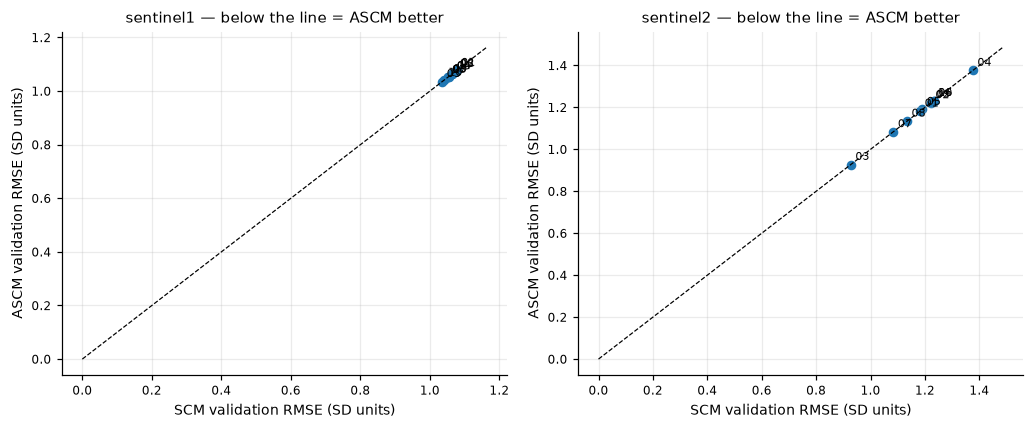

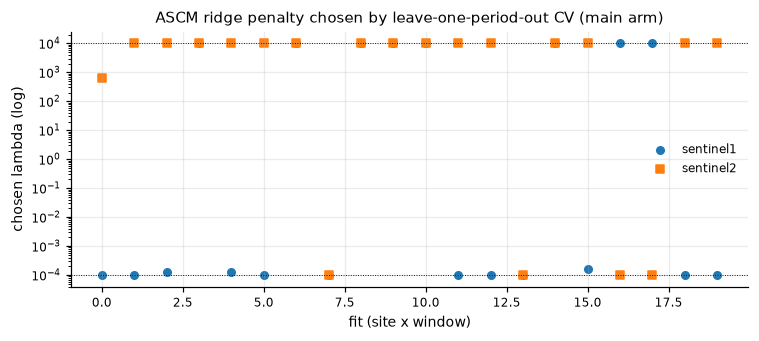

figures saved


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4), sharex=False)
for ax, sensor in zip(axes, SENSORS):
    t = cmp_.query("arm == 'main' and scheme == 'frozen_joint' and sensor == @sensor")
    lim = max(t["valid_rmse_scm"].max(), t["valid_rmse_ascm"].max()) * 1.08
    ax.plot([0, lim], [0, lim], color="k", lw=0.8, ls="--")
    ax.scatter(t["valid_rmse_scm"], t["valid_rmse_ascm"], s=28)
    for _, r in t.iterrows():
        ax.annotate(r["treatment_site_id"][-2:],
                    (r["valid_rmse_scm"], r["valid_rmse_ascm"]),
                    fontsize=7, xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel("SCM holdout RMSPE (SD units)")
    ax.set_ylabel("ASCM holdout RMSPE (SD units)")
    ax.set_title(f"{sensor} — below the line = ASCM better")
fig.tight_layout()
fig.savefig(TS / "panel_scm_vs_ascm.png", bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.2))
lt = lam_tab.query("arm == 'main'")
for sensor, marker in zip(SENSORS, "os"):
    s = lt.query("sensor == @sensor")
    ax.scatter(np.arange(len(s)), s["lambda"], marker=marker, s=24, label=sensor)
ax.set_yscale("log"); ax.axhline(LAMBDAS[0], color="k", lw=0.6, ls=":")
ax.axhline(LAMBDAS[-1], color="k", lw=0.6, ls=":")
ax.set_ylabel("chosen lambda (log)"); ax.set_xlabel("fit (site x window)")
ax.set_title("ASCM ridge penalty chosen by leave-one-period-out CV (main arm)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(TS / "panel_ascm_lambda.png", bbox_inches="tight")
plt.show()
print("figures saved")

## Reading

**ASCM is inert here.** 72 of 80 λ choices land on a grid boundary, the main-arm w8
fits have zero negative weights, weight distances from SCM are microscopic, and
holdout RMSPE matches SCM to the third decimal on every site (mean improvement 0.000,
5/10 sites "better" by numerical noise). Extrapolation never materializes: at most 0.7%
of the 980 latent values leave [0, 1]. The reason is notebook 02's finding — ridge
augmentation can only help when the donors *nearly* span the target and need a small
extrapolating correction; when the donor span is this far from the treated latent, the
CV correctly concludes that no amount of augmentation helps, and collapses ASCM back
onto SCM. This mirrors, in stronger form, the collaborator's feature-space result
(ASCM ≈ SCM for most fits, 9/20 at the λ ceiling).